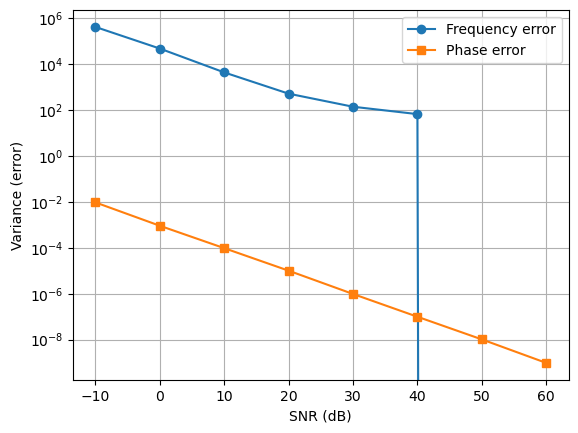

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1. SETUP ----------
N = 513                              # antall samples
n = np.arange(-256, 257)             # tidsindeks
T = 1e-6                             # samplingstid

f0 = 1e5                             # ekte frekvens (Hz)
omega0 = 2 * np.pi * f0              # ekte omega
phi_true = np.pi / 8                 # ekte fase

# ---------- 2. LAG SIGNAL ----------
def generate_signal(SNR_dB):
    # gjør om fra dB til vanlig tall
    SNR = 10**(SNR_dB / 10)
    
    # hvor mye støy vi skal ha
    sigma2 = 1 / (2 * SNR)

    # lag støy (real + imaginær)
    noise = (np.random.normal(0, np.sqrt(sigma2), N) +
             1j * np.random.normal(0, np.sqrt(sigma2), N))

    # rent signal + støy
    signal = np.exp(1j * (omega0 * n * T + phi_true))
    x = signal + noise

    return x

# ---------- 3. FINN FREKVENS ----------
def estimate_frequency(x, M):
    X = np.fft.fft(x, n=M)           # gå til frekvensdomene
    k_max = np.argmax(np.abs(X))     # finn største peak

    omega_hat = 2 * np.pi * k_max / (M * T)
    return omega_hat

# ---------- 4. FINN FASE ----------
def estimate_phase(x, omega_hat):
    # fjern frekvensen
    F = np.mean(x * np.exp(-1j * omega_hat * n * T))
    
    phi_hat = np.angle(F)
    return phi_hat

# ---------- 5. KJØR MANGE GANGER ----------
def simulate(SNR_dB, M, runs=500):
    freq_errors = []
    phase_errors = []

    for _ in range(runs):
        x = generate_signal(SNR_dB)

        omega_hat = estimate_frequency(x, M)
        phi_hat = estimate_phase(x, omega_hat)

        # sammenlign med fasit
        freq_errors.append(omega0 - omega_hat)
        phase_errors.append(phi_true - phi_hat)

    # hvor mye feil varierer
    return np.var(freq_errors), np.var(phase_errors)

# ---------- 6. TEST FOR FLERE SNR ----------
SNR_values = np.arange(-10, 61, 10)
M = 2**18

freq_variance = []
phase_variance = []

for snr in SNR_values:
    v_freq, v_phase = simulate(snr, M)
    freq_variance.append(v_freq)
    phase_variance.append(v_phase)

# ---------- 7. PLOT ----------
plt.figure()
plt.semilogy(SNR_values, freq_variance, 'o-', label='Frequency error')
plt.semilogy(SNR_values, phase_variance, 's-', label='Phase error')
plt.xlabel('SNR (dB)')
plt.ylabel('Variance (error)')
plt.legend()
plt.grid()
plt.show()

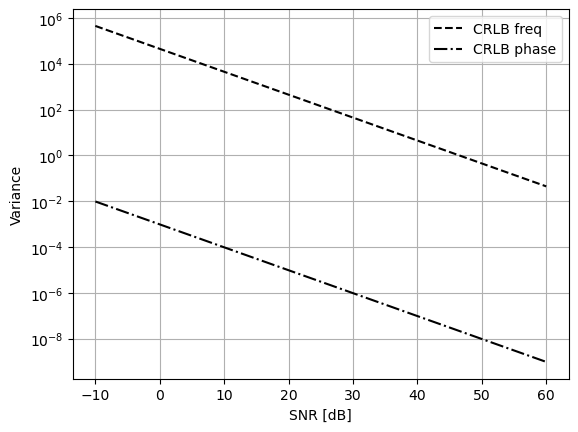

In [10]:
def crlb(SNR_dB):
    SNR = 10**(SNR_dB/10)
    sigma2 = 1/(2*SNR)

    n0 = -256
    P = N*(N-1)/2
    Q = N*(N-1)*(2*N-1)/6

    var_freq = (12*sigma2)/(T**2 * N * (N**2 - 1))
    var_phase = (12*sigma2*(n0**2*N + 2*n0*P + Q))/(N**2*(N**2 - 1))

    return var_freq, var_phase

freq_crlb = []
phase_crlb = []

for snr in SNR_values:
    vf, vp = crlb(snr)
    freq_crlb.append(vf)
    phase_crlb.append(vp)

plt.semilogy(SNR_values, freq_crlb, 'k--', label='CRLB freq')
plt.semilogy(SNR_values, phase_crlb, 'k-.', label='CRLB phase')
plt.xlabel("SNR [dB]")
plt.ylabel("Variance")
plt.legend()
plt.grid()
plt.show()

In [2]:
#Oppgave 1b
import numpy as np
from scipy.optimize import minimize

# --- Parametere ---
Fs = 1e6
T = 1/Fs
f0 = 1e5
w0 = 2*np.pi*f0
phi = np.pi/8
A = 1

N = 513
n = np.arange(-256, 257)

# --- Signal ---
sigma = 0.1  # juster for SNR
noise = np.random.normal(0, sigma, N) + 1j*np.random.normal(0, sigma, N)
x = A*np.exp(1j*(w0*n*T + phi)) + noise

# --- FFT-estimat ---
M = 2**10
X = np.fft.fft(x, M)
m = np.argmax(np.abs(X))
w_fft = 2*np.pi*m/(M*T)

# --- Finjustering ---
def F(w):
    return -np.abs(np.sum(x*np.exp(-1j*w*n*T))/N)

w_hat = minimize(F, [w_fft], method='Nelder-Mead').x[0]

# --- Fase ---
F_val = np.sum(x*np.exp(-1j*w_hat*n*T))/N
phi_hat = np.angle(F_val)

f_true = w0/(2*np.pi)
f_est = w_hat/(2*np.pi)

print("----- Results -----")
print(f"Frequency: {f_est:.2f} Hz (true: {f_true:.2f} Hz, error: {abs(f_est-f_true):.2f} Hz)")
print(f"Phase:     {phi_hat:.5f} rad (true: {phi:.5f} rad, error: {abs(phi_hat-phi):.5f})")

----- Results -----
Frequency: 99992.23 Hz (true: 100000.00 Hz, error: 7.77 Hz)
Phase:     0.40252 rad (true: 0.39270 rad, error: 0.00983)
